In [34]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Model
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from sklearn.model_selection import train_test_split
LR_SIZE = 128
HR_SIZE = 256
CHANNELS = 1
BATCH_SIZE = 4
EPOCHS = 10
SEED = 42
LEARNING_RATE = 1e-4
OUTPUT_DIR = Path(r"train")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = OUTPUT_DIR / "medr_net_best.h5"
LOG_CSV_PATH = OUTPUT_DIR / "training_log.csv"
LOSS_WEIGHTS = {
    "pixel": 1.0,
    "ssim": 0.6,
    "edge": 0.3,
    "perceptual": 0.1,
}

tf.random.set_seed(SEED)
np.random.seed(SEED)
DATASET_DIR = Path(r"train/Preprocessed_Augmented")
GT_DIR = DATASET_DIR / "GT"
LR_DIR = DATASET_DIR / "NoisyLR"
IMG_SIZE = 256
gt_files = sorted(GT_DIR.glob("*.npy"))
pairs = []
for gt_path in gt_files:
    lr_path = LR_DIR / gt_path.name
    if lr_path.exists():
        pairs.append((str(lr_path), str(gt_path)))

train_pairs, temp_pairs = train_test_split(pairs, test_size=0.20, random_state=SEED)
val_pairs, test_pairs = train_test_split(temp_pairs, test_size=0.50, random_state=SEED)


In [35]:
def _load_npy_pair(lr_path, gt_path):
    lr_img = np.load(lr_path.numpy().decode("utf-8")).astype(np.float32)
    gt_img = np.load(gt_path.numpy().decode("utf-8")).astype(np.float32)

    def _normalize(img):
        min_val = img.min()
        max_val = img.max()
        if max_val > min_val:
            img = (img - min_val) / (max_val - min_val)
        else:
            img = np.zeros_like(img)
        return img

    lr_img = _normalize(lr_img)
    gt_img = _normalize(gt_img)

    if lr_img.ndim == 2:
        lr_img = lr_img[..., np.newaxis]
    if gt_img.ndim == 2:
        gt_img = gt_img[..., np.newaxis]

    return lr_img, gt_img


def _tf_load_pair(lr_path, gt_path):
    lr_img, gt_img = tf.py_function(
        func=_load_npy_pair,
        inp=[lr_path, gt_path],
        Tout=[tf.float32, tf.float32],
    )
    lr_img.set_shape([LR_SIZE, LR_SIZE, CHANNELS])
    gt_img.set_shape([HR_SIZE, HR_SIZE, CHANNELS])
    return lr_img, gt_img


def build_dataset(pairs, batch_size, shuffle=False, cache_path=None):
    lr_paths = [p[0] for p in pairs]
    gt_paths = [p[1] for p in pairs]
    ds = tf.data.Dataset.from_tensor_slices((lr_paths, gt_paths))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(pairs), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(_tf_load_pair, num_parallel_calls=tf.data.AUTOTUNE)
    if cache_path is not None:
        
        ds = ds.cache(cache_path)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_dataset = build_dataset(
    train_pairs, BATCH_SIZE, shuffle=True, cache_path=str(OUTPUT_DIR / "train_cache")
)
val_dataset = build_dataset(
    val_pairs, BATCH_SIZE, shuffle=False, cache_path=str(OUTPUT_DIR / "val_cache")
)
test_dataset = build_dataset(test_pairs, BATCH_SIZE, shuffle=False)

In [25]:
def degradation_aware_extraction(x, filters=64, name="dafe"):
    feat = layers.Conv2D(filters, 3, padding="same", name=f"{name}_conv1")(x)
    feat = layers.LeakyReLU(0.2, name=f"{name}_act1")(feat)

    gate = layers.GlobalAveragePooling2D(name=f"{name}_gap")(feat)
    gate = layers.Dense(filters // 4, activation="relu", name=f"{name}_fc1")(gate)
    gate = layers.Dense(filters, activation="sigmoid", name=f"{name}_fc2")(gate)
    gate = layers.Reshape((1, 1, filters), name=f"{name}_reshape")(gate)

    feat = layers.Multiply(name=f"{name}_gate_mul")([feat, gate])
    feat = layers.Conv2D(filters, 3, padding="same", name=f"{name}_conv2")(feat)
    feat = layers.LeakyReLU(0.2, name=f"{name}_act2")(feat)
    return feat


def multi_scale_residual_block(x, filters=64, block_id=0):
    name = f"msrl_{block_id}"
    branch1 = layers.Conv2D(filters, 3, padding="same", dilation_rate=1, name=f"{name}_b1")(x)
    branch2 = layers.Conv2D(filters, 3, padding="same", dilation_rate=2, name=f"{name}_b2")(x)
    branch3 = layers.Conv2D(filters, 3, padding="same", dilation_rate=4, name=f"{name}_b3")(x)

    fused = layers.Concatenate(name=f"{name}_concat")([branch1, branch2, branch3])
    fused = layers.Conv2D(filters, 1, padding="same", name=f"{name}_fuse")(fused)
    fused = layers.LeakyReLU(0.2, name=f"{name}_act")(fused)

    out = layers.Add(name=f"{name}_residual")([x, fused])
    return out


def multi_scale_residual_learning(x, filters=64, num_blocks=6):
    for i in range(num_blocks):
        x = multi_scale_residual_block(x, filters=filters, block_id=i)
    return x


def sobel_edge_map(x):
    edges = tf.image.sobel_edges(x)
    edges = tf.sqrt(tf.reduce_sum(tf.square(edges), axis=-1) + 1e-8)
    return edges


def edge_aware_enhancement(x, filters=64, name="ease"):
    edge_map = layers.Lambda(sobel_edge_map, name=f"{name}_sobel")(x)
    edge_feat = layers.Conv2D(filters, 3, padding="same", name=f"{name}_conv1")(edge_map)
    edge_feat = layers.LeakyReLU(0.2, name=f"{name}_act1")(edge_feat)

    attention = layers.Conv2D(filters, 1, padding="same", activation="sigmoid", name=f"{name}_attn")(edge_feat)
    enhanced = layers.Multiply(name=f"{name}_apply")([x, attention])
    enhanced = layers.Add(name=f"{name}_residual")([x, enhanced])
    return enhanced, edge_feat


def learned_super_resolution(x, filters=64, scale=2, name="lsrr"):
    x = layers.Conv2D(filters * (scale ** 2), 3, padding="same", name=f"{name}_pre_conv")(x)
    x = layers.Lambda(
        lambda t: tf.nn.depth_to_space(t, scale), name=f"{name}_pixel_shuffle"
    )(x)
    x = layers.Conv2D(filters, 3, padding="same", name=f"{name}_post_conv")(x)
    x = layers.LeakyReLU(0.2, name=f"{name}_act")(x)
    return x


def adaptive_feature_fusion(denoised, structural, high_freq, filters=64, name="aff"):
    concat = layers.Concatenate(name=f"{name}_concat")([denoised, structural, high_freq])
    weights = layers.Conv2D(3, 1, padding="same", activation="softmax", name=f"{name}_weights")(concat)

    w0 = layers.Lambda(lambda t: t[..., 0:1], name=f"{name}_w0")(weights)
    w1 = layers.Lambda(lambda t: t[..., 1:2], name=f"{name}_w1")(weights)
    w2 = layers.Lambda(lambda t: t[..., 2:3], name=f"{name}_w2")(weights)

    fused = layers.Add(name=f"{name}_fuse")([
        layers.Multiply()([denoised, w0]),
        layers.Multiply()([structural, w1]),
        layers.Multiply()([high_freq, w2]),
    ])
    fused = layers.Conv2D(filters, 3, padding="same", name=f"{name}_conv")(fused)
    fused = layers.LeakyReLU(0.2, name=f"{name}_act")(fused)
    return fused


def build_medr_net(lr_size=LR_SIZE, channels=CHANNELS, filters=64):
    inputs = layers.Input(shape=(lr_size, lr_size, channels), name="lr_input")

    dafe_feat = degradation_aware_extraction(inputs, filters=filters)
    denoised_feat = multi_scale_residual_learning(dafe_feat, filters=filters, num_blocks=6)
    structural_feat, edge_feat = edge_aware_enhancement(denoised_feat, filters=filters)

    upsampled_denoised = learned_super_resolution(denoised_feat, filters=filters, scale=2, name="lsrr_denoised")
    upsampled_structural = learned_super_resolution(structural_feat, filters=filters, scale=2, name="lsrr_structural")
    upsampled_edge = learned_super_resolution(edge_feat, filters=filters, scale=2, name="lsrr_edge")

    fused = adaptive_feature_fusion(upsampled_denoised, upsampled_structural, upsampled_edge, filters=filters)

    fused = layers.Conv2D(filters, 3, padding="same", name="refine_conv1")(fused)
    fused = layers.LeakyReLU(0.2, name="refine_act1")(fused)
    fused = layers.Conv2D(filters // 2, 3, padding="same", name="refine_conv2")(fused)
    fused = layers.LeakyReLU(0.2, name="refine_act2")(fused)

    output = layers.Conv2D(channels, 3, padding="same", activation="sigmoid", name="restored_output")(fused)

    model = Model(inputs=inputs, outputs=output, name="MEDR_Net")
    return model


medr_net = build_medr_net()
medr_net.load_weights(CHECKPOINT_PATH)
medr_net.summary()


Model: "MEDR_Net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ lr_input (InputLayer)         │ (None, 128, 128, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dafe_conv1 (Conv2D)           │ (None, 128, 128, 64)      │             640 │ lr_input[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dafe_act1 (LeakyReLU)         │ (None, 128, 128, 64)      │               0 │ dafe_conv1[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dafe_gap                      │ (None, 64)                │               0 │ dafe_act1[0][0]            │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dafe_fc1 (Dense)              │ (None, 16)                │           1,040 │ dafe_gap[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dafe_fc2 (Dense)              │ (None, 64)                │           1,088 │ dafe_fc1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dafe_reshape (Reshape)        │ (None, 1, 1, 64)          │               0 │ dafe_fc2[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dafe_gate_mul (Multiply)      │ (None, 128, 128, 64)      │               0 │ dafe_act1[0][0],           │
│                               │                           │                 │ dafe_reshape[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dafe_conv2 (Conv2D)           │ (None, 128, 128, 64)      │          36,928 │ dafe_gate_mul[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dafe_act2 (LeakyReLU)         │ (None, 128, 128, 64)      │               0 │ dafe_conv2[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ msrl_0_b1 (Conv2D)            │ (None, 128, 128, 64)      │          36,928 │ dafe_act2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ msrl_0_b2 (Conv2D)            │ (None, 128, 128, 64)      │          36,928 │ dafe_act2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ msrl_0_b3 (Conv2D)            │ (None, 128, 128, 64)      │          36,928 │ dafe_act2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ msrl_0_concat (Concatenate)   │ (None, 128, 128, 192)     │               0 │ msrl_0_b1[0][0],           │
│                               │                           │                 │ msrl_0_b2[0][0],           │
│                               │                           │                 │ msrl_0_b3[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ msrl_0_fuse (Conv2D)          │ (None, 128, 128, 64)      │          12,352 │ msrl_0_concat[0][0]        │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 1,466,708 (5.60 MB)

 Trainable params: 1,466,708 (5.60 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
vgg = tf.keras.applications.VGG16(include_top=False, weights="imagenet", input_shape=(HR_SIZE, HR_SIZE, 3))
vgg.trainable = False
perceptual_extractor = Model(
    inputs=vgg.input,
    outputs=vgg.get_layer("block3_conv3").output,
    name="vgg_perceptual_extractor",
)


def pixel_loss(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))


def ssim_loss(y_true, y_pred):
    return 1.0 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))


def edge_loss(y_true, y_pred):
    edges_true = sobel_edge_map(y_true)
    edges_pred = sobel_edge_map(y_pred)
    return tf.reduce_mean(tf.abs(edges_true - edges_pred))


def perceptual_loss(y_true, y_pred):
    y_true_rgb = tf.image.grayscale_to_rgb(y_true) if y_true.shape[-1] == 1 else y_true
    y_pred_rgb = tf.image.grayscale_to_rgb(y_pred) if y_pred.shape[-1] == 1 else y_pred
    y_true_rgb = tf.keras.applications.vgg16.preprocess_input(y_true_rgb * 255.0)
    y_pred_rgb = tf.keras.applications.vgg16.preprocess_input(y_pred_rgb * 255.0)
    feat_true = perceptual_extractor(y_true_rgb)
    feat_pred = perceptual_extractor(y_pred_rgb)
    # L2-normalize feature vectors before comparing. Raw VGG activations
    # have unbounded, layer-dependent magnitude (often in the tens/hundreds),
    # which is why this term was dwarfing pixel/SSIM/edge (all bounded to
    # roughly [0, 1]) and dragging the composite loss into the thousands.
    # Normalizing bounds this term to [0, 4], on the same order as the rest.
    feat_true = tf.nn.l2_normalize(feat_true, axis=-1)
    feat_pred = tf.nn.l2_normalize(feat_pred, axis=-1)
    return tf.reduce_mean(tf.square(feat_true - feat_pred))


def composite_loss(y_true, y_pred):
    l_pixel = pixel_loss(y_true, y_pred)
    l_ssim = ssim_loss(y_true, y_pred)
    l_edge = edge_loss(y_true, y_pred)
    l_perc = perceptual_loss(y_true, y_pred)

    total = (
        LOSS_WEIGHTS["pixel"] * l_pixel
        + LOSS_WEIGHTS["ssim"] * l_ssim
        + LOSS_WEIGHTS["edge"] * l_edge
        + LOSS_WEIGHTS["perceptual"] * l_perc
    )
    return total, {"pixel": l_pixel, "ssim": l_ssim, "edge": l_edge, "perceptual": l_perc}

# ============================================================
# METRICS
# ============================================================
def psnr_metric(y_true, y_pred):
    return tf.reduce_mean(tf.image.psnr(y_true, y_pred, max_val=1.0))


def ssim_metric(y_true, y_pred):
    return tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))


def lpips_style_metric(y_true, y_pred):
    # VGG-feature-space distance used as a perceptual-similarity proxy.
    # This is NOT the official LPIPS metric (which uses a linear-calibrated
    # AlexNet/VGG stack trained on human judgments, typically via the
    # PyTorch `lpips` package). Use that package for publication-grade
    # LPIPS numbers; this proxy is for monitoring training only.
    return perceptual_loss(y_true, y_pred)

In [27]:
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0)

train_loss_tracker = tf.keras.metrics.Mean(name="train_loss")
val_loss_tracker = tf.keras.metrics.Mean(name="val_loss")
train_psnr_tracker = tf.keras.metrics.Mean(name="train_psnr")
val_psnr_tracker = tf.keras.metrics.Mean(name="val_psnr")
train_ssim_tracker = tf.keras.metrics.Mean(name="train_ssim")
val_ssim_tracker = tf.keras.metrics.Mean(name="val_ssim")

# Per-term breakdown so you can see which loss component is actually
# driving the total, instead of only watching one aggregate number.
train_pixel_tracker = tf.keras.metrics.Mean(name="train_pixel")
train_ssim_term_tracker = tf.keras.metrics.Mean(name="train_ssim_term")
train_edge_tracker = tf.keras.metrics.Mean(name="train_edge")
train_perceptual_tracker = tf.keras.metrics.Mean(name="train_perceptual")
val_pixel_tracker = tf.keras.metrics.Mean(name="val_pixel")
val_ssim_term_tracker = tf.keras.metrics.Mean(name="val_ssim_term")
val_edge_tracker = tf.keras.metrics.Mean(name="val_edge")
val_perceptual_tracker = tf.keras.metrics.Mean(name="val_perceptual")

In [28]:
@tf.function
def train_step(lr_batch, gt_batch):
    with tf.GradientTape() as tape:
        pred_batch = medr_net(lr_batch, training=True)
        loss, terms = composite_loss(gt_batch, pred_batch)
    gradients = tape.gradient(loss, medr_net.trainable_variables)
    optimizer.apply_gradients(zip(gradients, medr_net.trainable_variables))

    train_loss_tracker.update_state(loss)
    train_psnr_tracker.update_state(psnr_metric(gt_batch, pred_batch))
    train_ssim_tracker.update_state(ssim_metric(gt_batch, pred_batch))
    train_pixel_tracker.update_state(terms["pixel"])
    train_ssim_term_tracker.update_state(terms["ssim"])
    train_edge_tracker.update_state(terms["edge"])
    train_perceptual_tracker.update_state(terms["perceptual"])
    return loss


@tf.function
def val_step(lr_batch, gt_batch):
    pred_batch = medr_net(lr_batch, training=False)
    loss, terms = composite_loss(gt_batch, pred_batch)

    val_loss_tracker.update_state(loss)
    val_psnr_tracker.update_state(psnr_metric(gt_batch, pred_batch))
    val_ssim_tracker.update_state(ssim_metric(gt_batch, pred_batch))
    val_pixel_tracker.update_state(terms["pixel"])
    val_ssim_term_tracker.update_state(terms["ssim"])
    val_edge_tracker.update_state(terms["edge"])
    val_perceptual_tracker.update_state(terms["perceptual"])
    return loss

In [36]:
import time
import numpy as np
history = {"train_loss": [], "val_loss": [], "train_psnr": [], "val_psnr": [], "train_ssim": [], "val_ssim": []}
best_val_loss = np.inf
patience = 10
patience_counter = 0

log_rows = []

train_steps_per_epoch = max(1, (len(train_pairs) + BATCH_SIZE - 1) // BATCH_SIZE)
val_steps_per_epoch = max(1, (len(val_pairs) + BATCH_SIZE - 1) // BATCH_SIZE)

total_start_time = time.perf_counter()

lr_patience = 3
lr_patience_counter = 0
lr_decay_factor = 0.5
min_lr = 1e-6

for epoch in range(1, EPOCHS + 1):
    epoch_start_time = time.perf_counter()

    for tracker in (
        train_loss_tracker, val_loss_tracker,
        train_psnr_tracker, val_psnr_tracker,
        train_ssim_tracker, val_ssim_tracker,
        train_pixel_tracker, train_ssim_term_tracker, train_edge_tracker, train_perceptual_tracker,
        val_pixel_tracker, val_ssim_term_tracker, val_edge_tracker, val_perceptual_tracker,
    ):
        tracker.reset_state()

    total_steps = train_steps_per_epoch + val_steps_per_epoch
    POSTFIX_EVERY = 10

    epoch_bar = tqdm(
        total=total_steps,
        desc=f"Epoch {epoch:01d}/{EPOCHS}",
        unit="batch",
        leave=False,
        mininterval=0.3,
        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}{postfix}]",
    )

    for step, (lr_batch, gt_batch) in enumerate(train_dataset, start=1):
        train_step(lr_batch, gt_batch)
        epoch_bar.update(1)
        if step % POSTFIX_EVERY == 0 or step == train_steps_per_epoch:
            epoch_bar.set_postfix(
                phase="train",
                loss=f"{train_loss_tracker.result().numpy():.4f}",
                psnr=f"{train_psnr_tracker.result().numpy():.2f}",
                ssim=f"{train_ssim_tracker.result().numpy():.4f}",
            )

    for step, (lr_batch, gt_batch) in enumerate(val_dataset, start=1):
        val_step(lr_batch, gt_batch)
        epoch_bar.update(1)
        if step % POSTFIX_EVERY == 0 or step == val_steps_per_epoch:
            epoch_bar.set_postfix(
                phase="val",
                loss=f"{val_loss_tracker.result().numpy():.4f}",
                psnr=f"{val_psnr_tracker.result().numpy():.2f}",
                ssim=f"{val_ssim_tracker.result().numpy():.4f}",
            )

    epoch_bar.close()

    train_loss = train_loss_tracker.result().numpy()
    val_loss = val_loss_tracker.result().numpy()
    train_psnr = train_psnr_tracker.result().numpy()
    val_psnr = val_psnr_tracker.result().numpy()
    train_ssim = train_ssim_tracker.result().numpy()
    val_ssim = val_ssim_tracker.result().numpy()
    epoch_time = time.perf_counter() - epoch_start_time

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_psnr"].append(train_psnr)
    history["val_psnr"].append(val_psnr)
    history["train_ssim"].append(train_ssim)
    history["val_ssim"].append(val_ssim)

    log_rows.append([epoch, train_loss, val_loss, train_psnr, val_psnr, train_ssim, val_ssim, epoch_time])

    saved_flag = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        lr_patience_counter = 0
        medr_net.save(CHECKPOINT_PATH)
        saved_flag = " | saved best"
    else:
        patience_counter += 1
        lr_patience_counter += 1
        if lr_patience_counter >= lr_patience:
            current_lr = float(optimizer.learning_rate.numpy())
            new_lr = max(current_lr * lr_decay_factor, min_lr)
            if new_lr < current_lr:
                optimizer.learning_rate.assign(new_lr)
                saved_flag += f" | lr reduced {current_lr:.2e} -> {new_lr:.2e}"
            lr_patience_counter = 0

    print(
        f"Epoch {epoch:03d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
        f"train_psnr={train_psnr:.2f} val_psnr={val_psnr:.2f} | "
        f"train_ssim={train_ssim:.4f} val_ssim={val_ssim:.4f} | "
        f"time={epoch_time:.1f}s{saved_flag}"
    )
    print(
        f"    val terms -> pixel={val_pixel_tracker.result().numpy():.4f} "
        f"ssim={val_ssim_term_tracker.result().numpy():.4f} "
        f"edge={val_edge_tracker.result().numpy():.4f} "
        f"perceptual={val_perceptual_tracker.result().numpy():.4f}"
    )

    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch}")
        break

total_end_time = time.perf_counter()
total_training_time = total_end_time - total_start_time
total_minutes = total_training_time / 60.0
total_hours = total_training_time / 3600.0
print(f"Total training time : {total_training_time:.2f} seconds")
print(f"Total training time : {total_minutes:.2f} minutes")
print(f"Total training time : {total_hours:.2f} hours")

Epoch 001/10 | train_loss=0.2531 val_loss=0.2948 | train_psnr=23.19 val_psnr=21.01 | train_ssim=0.7497 val_ssim=0.7215 | time=108.9s | saved best
    val terms -> pixel=0.0818 ssim=0.2785 edge=0.1521 perceptual=0.0029


Epoch 002/10 | train_loss=0.2527 val_loss=0.2943 | train_psnr=23.21 val_psnr=21.04 | train_ssim=0.7501 val_ssim=0.7217 | time=105.8s | saved best
    val terms -> pixel=0.0815 ssim=0.2783 edge=0.1520 perceptual=0.0029


Epoch 003/10 | train_loss=0.2525 val_loss=0.2940 | train_psnr=23.22 val_psnr=21.04 | train_ssim=0.7503 val_ssim=0.7222 | time=106.4s | saved best
    val terms -> pixel=0.0814 ssim=0.2778 edge=0.1518 perceptual=0.0029


Epoch 004/10 | train_loss=0.2522 val_loss=0.2939 | train_psnr=23.23 val_psnr=21.05 | train_ssim=0.7505 val_ssim=0.7222 | time=106.6s | saved best
    val terms -> pixel=0.0814 ssim=0.2778 edge=0.1518 perceptual=0.0029


Epoch 005/10 | train_loss=0.2520 val_loss=0.2939 | train_psnr=23.24 val_psnr=21.02 | train_ssim=0.7507 val_ssim=0.7224 | time=105.2s
    val terms -> pixel=0.0816 ssim=0.2776 edge=0.1515 perceptual=0.0029


Epoch 006/10 | train_loss=0.2518 val_loss=0.2942 | train_psnr=23.24 val_psnr=21.03 | train_ssim=0.7508 val_ssim=0.7221 | time=105.5s
    val terms -> pixel=0.0816 ssim=0.2779 edge=0.1518 perceptual=0.0029


Epoch 007/10 | train_loss=0.2516 val_loss=0.2934 | train_psnr=23.26 val_psnr=21.04 | train_ssim=0.7511 val_ssim=0.7228 | time=104.8s | saved best
    val terms -> pixel=0.0814 ssim=0.2772 edge=0.1513 perceptual=0.0029


Epoch 008/10 | train_loss=0.2512 val_loss=0.2932 | train_psnr=23.27 val_psnr=21.08 | train_ssim=0.7514 val_ssim=0.7226 | time=105.8s | saved best
    val terms -> pixel=0.0810 ssim=0.2774 edge=0.1514 perceptual=0.0029


Epoch 009/10 | train_loss=0.2508 val_loss=0.2927 | train_psnr=23.30 val_psnr=21.06 | train_ssim=0.7520 val_ssim=0.7232 | time=105.1s | saved best
    val terms -> pixel=0.0811 ssim=0.2768 edge=0.1509 perceptual=0.0029


Epoch 010/10 | train_loss=0.2504 val_loss=0.2930 | train_psnr=23.31 val_psnr=21.06 | train_ssim=0.7522 val_ssim=0.7231 | time=105.7s
    val terms -> pixel=0.0813 ssim=0.2769 edge=0.1510 perceptual=0.0029
Total training time : 1060.79 seconds
Total training time : 17.68 minutes
Total training time : 0.29 hours


In [38]:
log_df1 = pd.DataFrame(
    log_rows,
    columns=["epoch", "train_loss", "val_loss", "train_psnr", "val_psnr", "train_ssim", "val_ssim", "epoch_time_sec"],
)
log_df = pd.concat([log_df, log_df1], ignore_index=True)
log_df['epoch'] = range(1, len(log_df) + 1)
log_df.to_csv(LOG_CSV_PATH, index=False)

In [39]:
log_df

,epoch,train_loss,val_loss,train_psnr,val_psnr,train_ssim,val_ssim,epoch_time_sec
0,1,0.270042,0.304739,22.376448,20.773930,0.735850,0.711149,124.515292
1,2,0.262254,0.303274,22.752733,20.804291,0.741565,0.713197,105.208389
2,3,0.261359,0.302727,22.797911,20.808426,0.742350,0.713832,105.866820
3,4,0.260488,0.302825,22.840832,20.799534,0.743111,0.714079,105.965455
4,5,0.259911,0.302479,22.866398,20.801386,0.743699,0.714462,105.940776
5,6,0.259403,0.302544,22.885975,20.780924,0.744163,0.714986,106.022803
6,7,0.258943,0.301357,22.896288,20.807734,0.744732,0.716050,105.582608
7,8,0.258657,0.301287,22.902225,20.814529,0.744904,0.716236,103.057414
8,9,0.258337,0.300645,22.914867,20.835590,0.745274,0.716595,103.614630
9,10,0.258104,0.300511,22.936722,20.866398,0.745217,0.716418,104.789749


In [40]:
test_psnr_tracker = tf.keras.metrics.Mean(name="test_psnr")
test_ssim_tracker = tf.keras.metrics.Mean(name="test_ssim")
test_lpips_tracker = tf.keras.metrics.Mean(name="test_lpips_style")

best_model = build_medr_net()
best_model.load_weights(CHECKPOINT_PATH)

for lr_batch, gt_batch in test_dataset:
    pred_batch = best_model(lr_batch, training=False)
    test_psnr_tracker.update_state(psnr_metric(gt_batch, pred_batch))
    test_ssim_tracker.update_state(ssim_metric(gt_batch, pred_batch))
    test_lpips_tracker.update_state(lpips_style_metric(gt_batch, pred_batch))

print("\n=== Test Set Results ===")
print(f"PSNR: {test_psnr_tracker.result().numpy():.3f} dB")
print(f"SSIM: {test_ssim_tracker.result().numpy():.4f}")
print(f"LPIPS-style (VGG proxy): {test_lpips_tracker.result().numpy():.4f}")


=== Test Set Results ===
PSNR: 23.523 dB
SSIM: 0.7343
LPIPS-style (VGG proxy): 0.0026


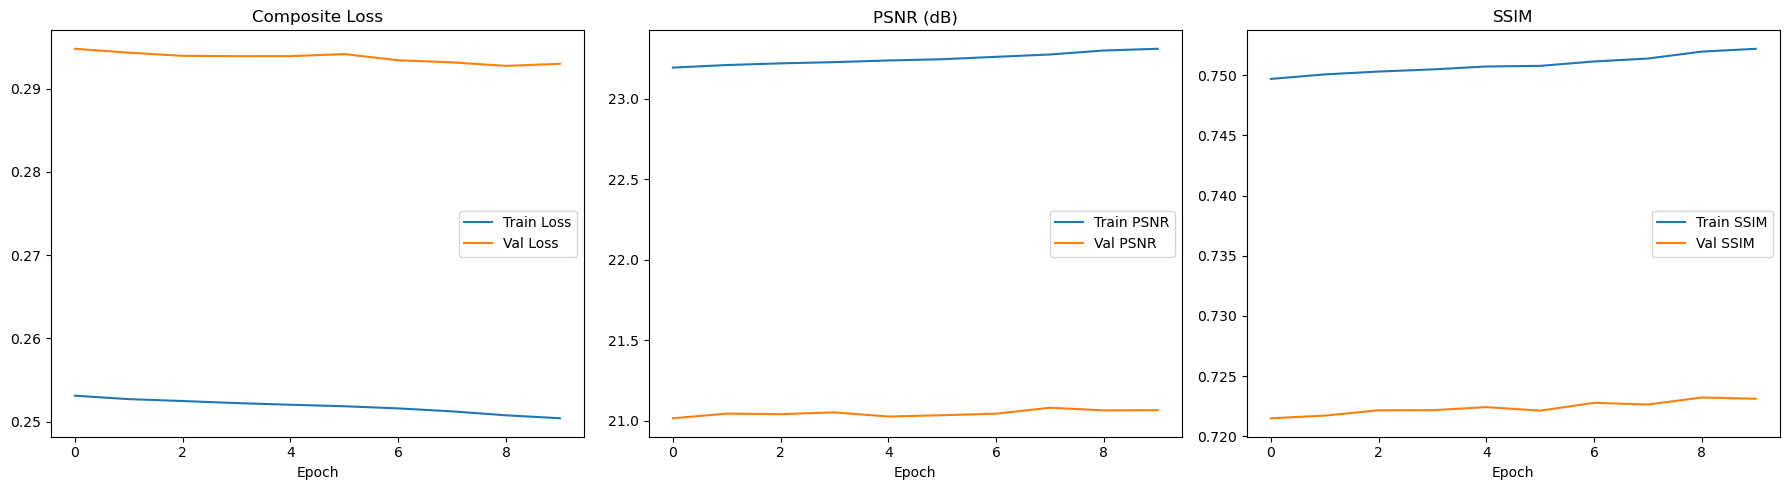

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_title("Composite Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_psnr"], label="Train PSNR")
axes[1].plot(history["val_psnr"], label="Val PSNR")
axes[1].set_title("PSNR (dB)")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(history["train_ssim"], label="Train SSIM")
axes[2].plot(history["val_ssim"], label="Val SSIM")
axes[2].set_title("SSIM")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150)
plt.show()